In [33]:
pip install xgboost

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [35]:
!pip install seaborn


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [43]:
! pip install shap


  Using cached shap-0.52.0-cp312-abi3-win_amd64.whl.metadata (26 kB)
Using cached shap-0.52.0-cp312-abi3-win_amd64.whl (499 kB)



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [38]:
print("train_df 컬럼 개수:", len(train_df.columns))
print(train_df.columns.tolist())

X_train, y_train = prepare_data(train_df)

print("X_train 컬럼 개수:", len(X_train.columns))
print(X_train.columns.tolist())
print(X_train.shape)

train_df 컬럼 개수: 2
['msno', 'is_churn']
X_train 컬럼 개수: 0
[]
(992931, 0)


train shape: (992931, 2)
val shape: (165074, 42)
test shape: (165074, 42)

[주의] train_v1에는 feature가 없어서 val.csv를 학습용으로 사용합니다.

최종 X_train shape: (165074, 36)
최종 X_test shape: (165074, 36)

===== 성능 결과 =====
AUC: 0.9923190603665686
F1: 0.8729379418695994
Log Loss: 0.04699270236831937
Accuracy: 0.9843221827786326
Precision: 0.9247893477582441
Recall: 0.8265922826592282

===== Classification Report =====
              precision    recall  f1-score   support

           0       0.99      1.00      0.99    154319
           1       0.92      0.83      0.87     10755

    accuracy                           0.98    165074
   macro avg       0.96      0.91      0.93    165074
weighted avg       0.98      0.98      0.98    165074


성능 CSV 저장 완료: ./xgboost_outputs\xgboost_performance.csv


<Figure size 600x500 with 0 Axes>

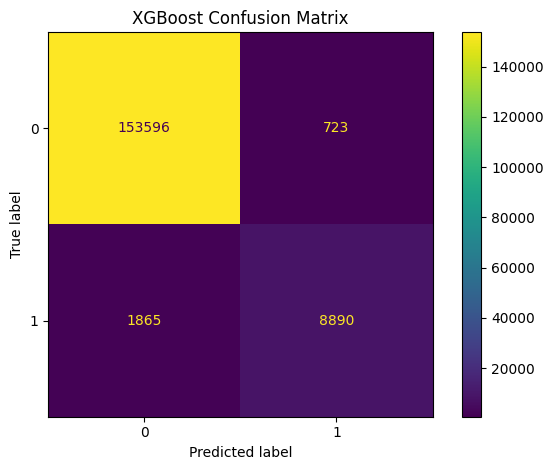

Confusion Matrix 저장 완료: ./xgboost_outputs\xgboost_confusion_matrix.png


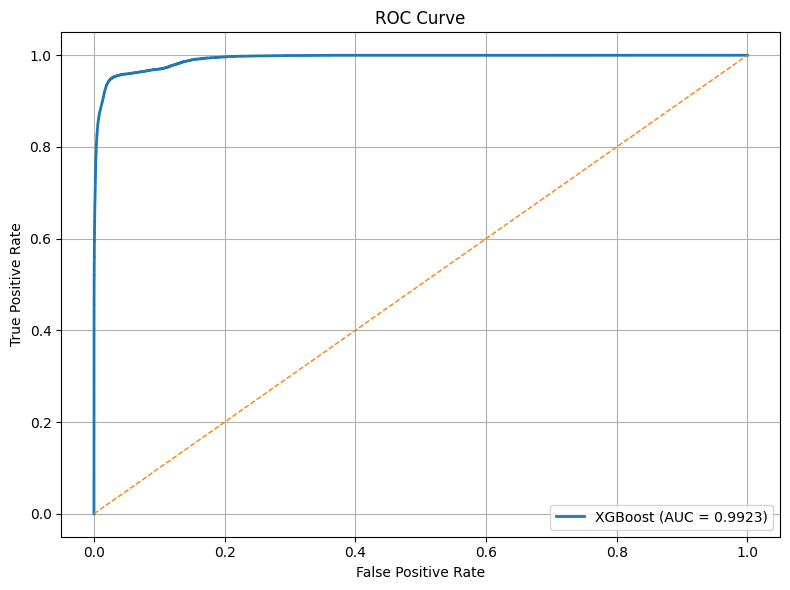

ROC Curve 저장 완료: ./xgboost_outputs\xgboost_roc_curve.png


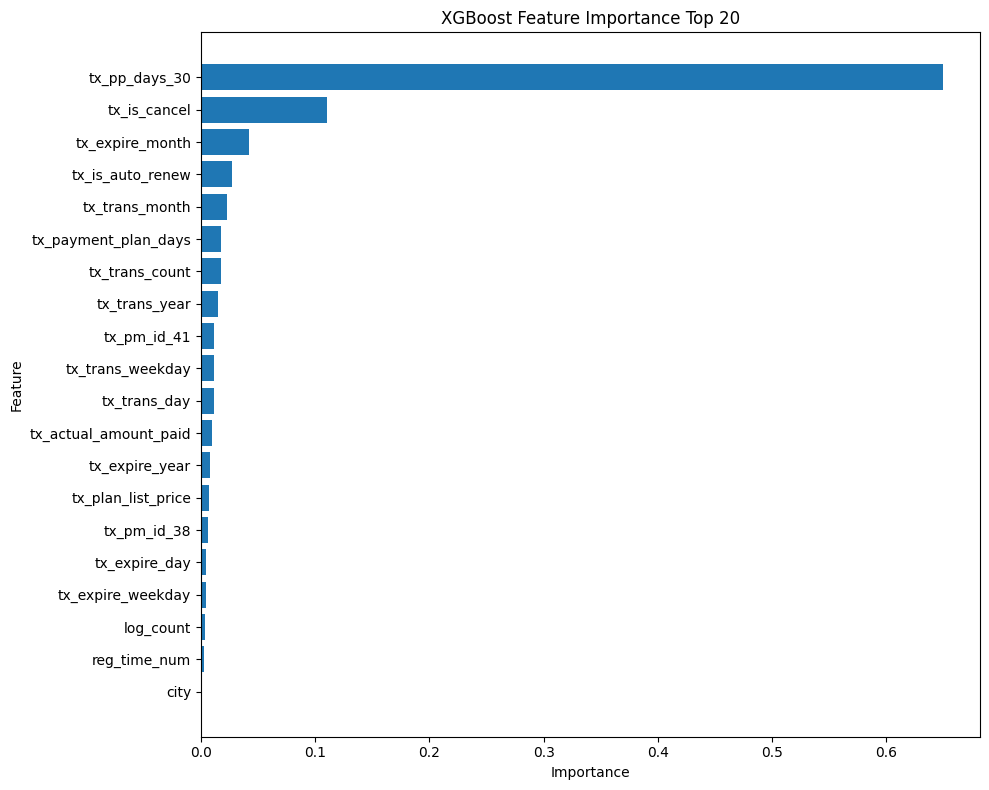

Feature Importance CSV 저장 완료: ./xgboost_outputs\xgboost_feature_importance.csv
Feature Importance 그래프 저장 완료: ./xgboost_outputs\xgboost_feature_importance_top20.png


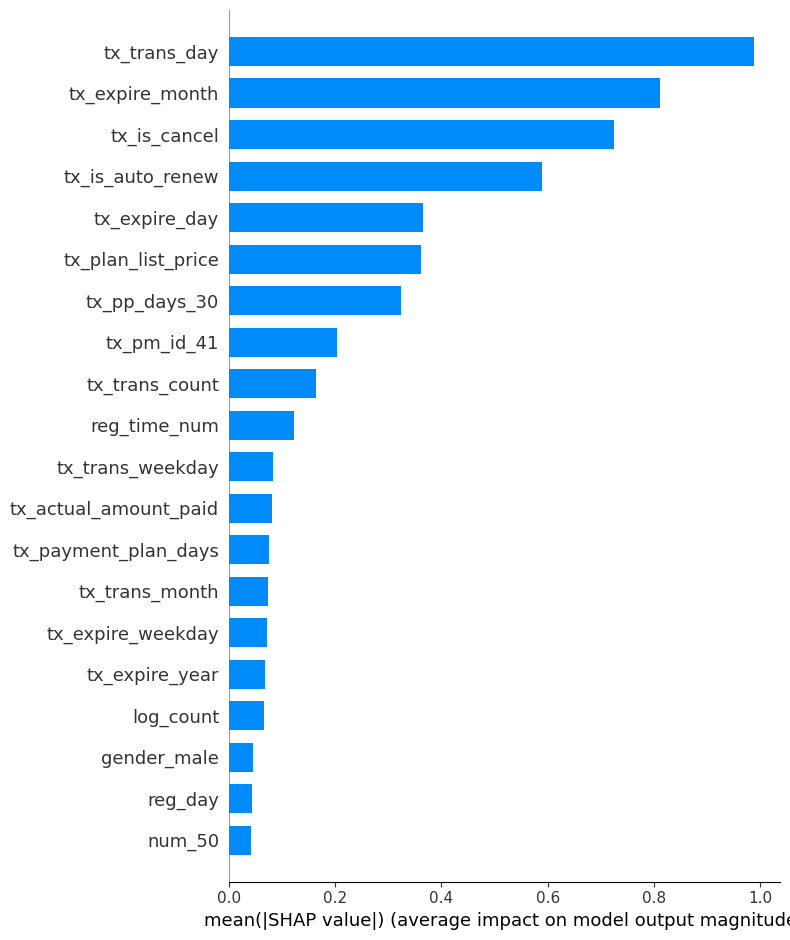

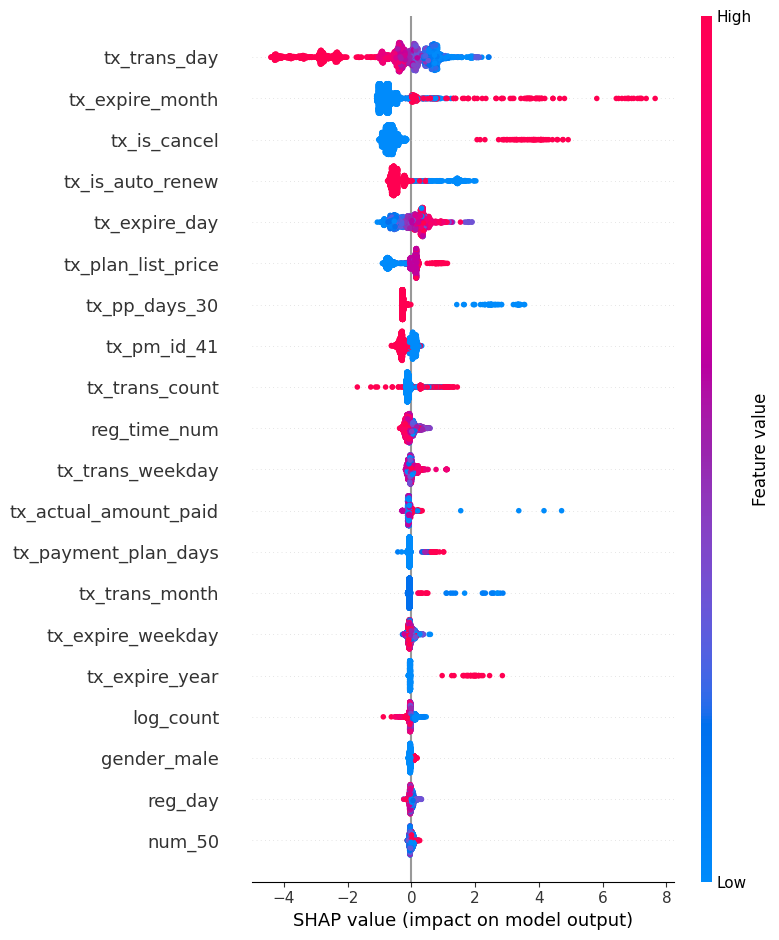

SHAP Bar 그래프 저장 완료: ./xgboost_outputs\xgboost_shap_bar_top20.png
SHAP Beeswarm 그래프 저장 완료: ./xgboost_outputs\xgboost_shap_beeswarm_top20.png

예측 결과 CSV 저장 완료: ./xgboost_outputs\xgboost_predictions.csv

전체 완료!
저장 폴더: ./xgboost_outputs


In [47]:
# ===============================
# XGBoost 이탈률 예측 전체 실행 코드
# 성능 CSV + Feature Importance 그래프 + SHAP 그래프 저장
# ===============================

import os
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from xgboost import XGBClassifier
from sklearn.metrics import (
    roc_auc_score,
    f1_score,
    log_loss,
    accuracy_score,
    precision_score,
    recall_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# ===============================
# 1. 경로 설정
# ===============================

TRAIN_PATH = ("./data/train_v1.csv")
VAL_PATH = ("./data/val.csv")
TEST_PATH = ("./data/test.csv")

OUTPUT_DIR = "./xgboost_outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ===============================
# 2. 데이터 불러오기
# ===============================

train_df = pd.read_csv(TRAIN_PATH)
val_df = pd.read_csv(VAL_PATH)
test_df = pd.read_csv(TEST_PATH)

print("train shape:", train_df.shape)
print("val shape:", val_df.shape)
print("test shape:", test_df.shape)

# ===============================
# 3. 학습/평가 데이터 결정
# ===============================
# train_v1 파일에 feature가 없고 msno, is_churn만 있으면
# val을 학습 데이터로, test를 평가 데이터로 사용

if train_df.shape[1] <= 2:
    print("\n[주의] train_v1에는 feature가 없어서 val.csv를 학습용으로 사용합니다.")
    model_train_df = val_df.copy()
    model_test_df = test_df.copy()
else:
    model_train_df = train_df.copy()
    model_test_df = test_df.copy()

# ===============================
# 4. X, y 분리
# ===============================

target_col = "is_churn"

drop_cols = [
    "msno",
    "is_churn",
    "registration_init_time",
    "tx_transaction_date",
    "tx_membership_expire_date",
    "last_listen_date"
]

drop_cols = [col for col in drop_cols if col in model_train_df.columns]

X_train = model_train_df.drop(columns=drop_cols)
y_train = model_train_df[target_col]

X_test = model_test_df.drop(columns=drop_cols)
y_test = model_test_df[target_col]

# train/test 컬럼 맞추기
X_test = X_test.reindex(columns=X_train.columns)

# bool 컬럼 int로 변환
for col in X_train.columns:
    if X_train[col].dtype == "bool":
        X_train[col] = X_train[col].astype(int)
        X_test[col] = X_test[col].astype(int)

# 숫자형만 사용
X_train = X_train.select_dtypes(include=["int64", "float64", "int32", "float32", "bool"])
X_test = X_test[X_train.columns]

# 결측치 처리
X_train = X_train.fillna(0)
X_test = X_test.fillna(0)

print("\n최종 X_train shape:", X_train.shape)
print("최종 X_test shape:", X_test.shape)

# ===============================
# 5. XGBoost 모델 학습
# ===============================

xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(X_train, y_train)

# ===============================
# 6. 예측 및 성능 평가
# ===============================

y_pred = xgb_model.predict(X_test)
y_proba = xgb_model.predict_proba(X_test)[:, 1]

auc = roc_auc_score(y_test, y_proba)
f1 = f1_score(y_test, y_pred)
ll = log_loss(y_test, y_proba)
acc = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)

print("\n===== 성능 결과 =====")
print("AUC:", auc)
print("F1:", f1)
print("Log Loss:", ll)
print("Accuracy:", acc)
print("Precision:", precision)
print("Recall:", recall)

print("\n===== Classification Report =====")
print(classification_report(y_test, y_pred))

# ===============================
# 7. 성능 CSV 저장
# ===============================

performance_df = pd.DataFrame({
    "model": ["XGBoost"],
    "auc": [auc],
    "f1": [f1],
    "log_loss": [ll],
    "accuracy": [acc],
    "precision": [precision],
    "recall": [recall]
})

performance_path = os.path.join(OUTPUT_DIR, "xgboost_performance.csv")
performance_df.to_csv(performance_path, index=False, encoding="utf-8-sig")

print("\n성능 CSV 저장 완료:", performance_path)

# ===============================
# 8. Confusion Matrix 저장
# ===============================

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(values_format="d")
plt.title("XGBoost Confusion Matrix")
plt.tight_layout()

cm_path = os.path.join(OUTPUT_DIR, "xgboost_confusion_matrix.png")
plt.savefig(cm_path, dpi=300)
plt.show()

print("Confusion Matrix 저장 완료:", cm_path)

# ===============================
# ROC Curve
# ===============================

from sklearn.metrics import roc_curve, roc_auc_score

fpr, tpr, thresholds = roc_curve(y_test, y_proba)
auc_score = roc_auc_score(y_test, y_proba)

plt.figure(figsize=(8,6))

plt.plot(
    fpr,
    tpr,
    linewidth=2,
    label=f"XGBoost (AUC = {auc_score:.4f})"
)

# 랜덤 예측 기준선
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    linewidth=1
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.grid(True)

plt.tight_layout()

roc_path = os.path.join(
    OUTPUT_DIR,
    "xgboost_roc_curve.png"
)

plt.savefig(roc_path, dpi=300)
plt.show()

print("ROC Curve 저장 완료:", roc_path)

# ===============================
# 9. Feature Importance 저장
# ===============================

importance_df = pd.DataFrame({
    "feature": X_train.columns,
    "importance": xgb_model.feature_importances_
}).sort_values(by="importance", ascending=False)

importance_csv_path = os.path.join(OUTPUT_DIR, "xgboost_feature_importance.csv")
importance_df.to_csv(importance_csv_path, index=False, encoding="utf-8-sig")

top_n = 20
top_importance = importance_df.head(top_n).sort_values(by="importance", ascending=True)

plt.figure(figsize=(10, 8))
plt.barh(top_importance["feature"], top_importance["importance"])
plt.title("XGBoost Feature Importance Top 20")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()

fi_path = os.path.join(OUTPUT_DIR, "xgboost_feature_importance_top20.png")
plt.savefig(fi_path, dpi=300)
plt.show()

print("Feature Importance CSV 저장 완료:", importance_csv_path)
print("Feature Importance 그래프 저장 완료:", fi_path)

# ===============================
# 10. SHAP 분석
# ===============================

try:
    import shap
except ModuleNotFoundError:
    print("\nshap이 설치되어 있지 않습니다.")
    print("아래 명령어를 한 번 실행한 뒤 다시 실행하세요.")
    print("pip install shap")
    shap = None

if shap is not None:
    # SHAP은 데이터가 많으면 오래 걸려서 일부만 샘플링
    shap_sample_size = min(3000, len(X_test))
    X_shap = X_test.sample(shap_sample_size, random_state=42)

    explainer = shap.TreeExplainer(xgb_model)
    shap_values = explainer.shap_values(X_shap)

    # SHAP Bar Plot
    plt.figure()
    shap.summary_plot(
        shap_values,
        X_shap,
        plot_type="bar",
        show=False,
        max_display=20
    )
    shap_bar_path = os.path.join(OUTPUT_DIR, "xgboost_shap_bar_top20.png")
    plt.tight_layout()
    plt.savefig(shap_bar_path, dpi=300, bbox_inches="tight")
    plt.show()

    # SHAP Beeswarm Plot
    plt.figure()
    shap.summary_plot(
        shap_values,
        X_shap,
        show=False,
        max_display=20
    )
    shap_beeswarm_path = os.path.join(OUTPUT_DIR, "xgboost_shap_beeswarm_top20.png")
    plt.tight_layout()
    plt.savefig(shap_beeswarm_path, dpi=300, bbox_inches="tight")
    plt.show()

    print("SHAP Bar 그래프 저장 완료:", shap_bar_path)
    print("SHAP Beeswarm 그래프 저장 완료:", shap_beeswarm_path)

# ===============================
# 11. 예측 결과 CSV 저장
# ===============================

prediction_df = pd.DataFrame({
    "msno": model_test_df["msno"],
    "y_true": y_test,
    "y_pred": y_pred,
    "churn_probability": y_proba
})

pred_path = os.path.join(OUTPUT_DIR, "xgboost_predictions.csv")
prediction_df.to_csv(pred_path, index=False, encoding="utf-8-sig")

print("\n예측 결과 CSV 저장 완료:", pred_path)

print("\n전체 완료!")
print("저장 폴더:", OUTPUT_DIR)